In [233]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from typing import TypedDict, Literal, Annotated, Any
from dotenv import load_dotenv
from uuid import uuid4
import operator

load_dotenv()

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [234]:
DEFAULT_MAX_RETRIES = 2

In [235]:
AgentType = Literal["research", "data", "writing"]
SubtaskStatus = Literal["pending", "running", "passed", "failed", "escalated"]
WorkflowStatus = Literal[
    "initialised",
    "planning",
    "executing",
    "reviewing",
    "completed",
    "failed",
    "escalated",
]

In [236]:
class Subtask(TypedDict):
    id: str
    agent_type: AgentType
    objective: str
    expected_output: str
    tools_allowed: list[str]
    review_criteria: list[str]
    status: SubtaskStatus
    retry_count: int

class SubtaskResult(TypedDict):
    subtask_id: str
    agent_type: AgentType
    output: Any
    confidence: float
    sources: list[dict]
    errors: list[str]

class ReviewReport(TypedDict):
    subtask_id: str
    passed: bool
    score: float
    issues: list[str]
    action: Literal["pass", "retry", "reassign", "escalate"]


class FinalReview(TypedDict):
    passed: bool
    score: float
    issues: list[str]
    action: Literal["return", "retry", "replan", "escalate"]

In [237]:
class SupervisorState(TypedDict, total=False):
    # Request identity
    task_id: str
    user_id: str
    user_request: str

    # Workflow status
    status: WorkflowStatus
    error: str | None

    # Planning
    plan: dict
    plan_confidence: float
    subtasks: list[Subtask]

    # Current execution pointer
    current_subtask_id: str | None

    # Specialist outputs
    subtask_results: dict[str, SubtaskResult]

    # Reviews
    review_reports: Annotated[list[ReviewReport], operator.add]
    final_review: FinalReview | None

    # Retry / escalation
    max_retries: int
    escalation_reason: str | None

    # Final response
    final_answer: str | None

In [238]:
from pydantic import BaseModel, Field, ConfigDict, model_validator

class PlannedSubtaskSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    agent_type: AgentType = Field(description="The specialist agent type that should handle this subtask.")
    objective: str = Field(
        description="A clear, specific instruction describing what this specialist must accomplish for this subtask."
    )
    expected_output: str = Field(
        description="The expected deliverable from this subtask, including the desired format or contents where relevant."
    )
    review_criteria: list[str] = Field(
        default_factory=list,
        description="A checklist the reviewer should use to judge whether this subtask was completed successfully."
    )

class SupervisorPlanSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    plan: str = Field(
        description=(
            "A concise high-level execution plan for completing the user request. "
            "Describe the overall approach, not runtime details like ids, retries, "
            "statuses, or tool permissions."
        ),
    )

    plan_confidence: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Confidence that the plan is suitable for the user request. "
            "Use 0.0 for no confidence and 1.0 for very high confidence."
        ),
    )

    subtasks: list[PlannedSubtaskSchema] = Field(
        min_length=1,
        description=(
            "Ordered subtasks to execute sequentially. "
            "The graph will run these in the given order."
        ),
    )

class ReviewDecisionSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    passed: bool = Field(
        description=(
            "Whether the specialist output satisfies the subtask objective, "
            "expected output, and review criteria."
        )
    )

    score: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Quality score for the specialist output. "
            "Use 0.0 for unusable output and 1.0 for excellent output."
        ),
    )

    issues: list[str] = Field(
        default_factory=list,
        description=(
            "Specific problems found during review. "
            "Leave empty only if the output passes without concerns."
        ),
    )

    action: Literal["pass", "retry", "reassign", "escalate"] = Field(
        description=(
            "The next action for this subtask. "
            "Use 'pass' if the result is acceptable, 'retry' if the same specialist "
            "should try again, 'reassign' if a different specialist should handle it, "
            "or 'escalate' if human review is needed."
        )
    )

    @model_validator(mode="after")
    def validate_action_matches_passed(self) -> "ReviewDecisionSchema":
        if self.passed and self.action != "pass":
            raise ValueError("A passed review must use action='pass'.")

        if not self.passed and self.action == "pass":
            raise ValueError("A failed review cannot use action='pass'.")

        return self

class WritingResponseSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    content: str = Field(
        min_length=20,
        description=(
            "The user-facing contentanswer produced by the writing agent. "
            "It should satisfy the writing subtask objective and use the approved "
            "previous subtask results."
        ),
    )

    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Confidence in the quality and completeness of the content. "
            "Use 0.0 for no confidence and 1.0 for very high confidence."
        ),
    )

In [239]:
# Helpers

def get_current_subtask(state: SupervisorState) -> Subtask | None:
    current_id = state.get("current_subtask_id")
    if not current_id:
        return None

    for subtask in state.get("subtasks", []):
        if subtask["id"] == current_id:
            return subtask

    return None

def update_subtask(
    state: SupervisorState,
    subtask_id: str,
    **updates,
) -> list[Subtask]:
    updated_subtasks: list[Subtask] = []

    for subtask in state.get("subtasks", []):
        if subtask["id"] == subtask_id:
            updated_subtasks.append({**subtask, **updates})
        else:
            updated_subtasks.append(subtask)

    return updated_subtasks

def all_subtasks_passed(state: SupervisorState) -> bool:
    subtasks = state.get("subtasks", [])

    if not subtasks:
        return False

    return all(subtask.get("status") == "passed" for subtask in subtasks)


In [240]:
TOOLS_BY_AGENT_TYPE: dict[AgentType, list[str]] = {
    "research": ["web_search"],
    "data": [],
    "writing": [],
}

In [241]:
def build_runtime_subtasks(
    planned_subtasks: list[PlannedSubtaskSchema],
) -> list[Subtask]:
    subtasks: list[Subtask] = []

    for index, planned_subtask in enumerate(planned_subtasks, start=1):
        subtasks.append(
            {
                "id": f"s{index}",
                "agent_type": planned_subtask.agent_type,
                "objective": planned_subtask.objective,
                "expected_output": planned_subtask.expected_output,
                "tools_allowed": TOOLS_BY_AGENT_TYPE[planned_subtask.agent_type],
                "review_criteria": planned_subtask.review_criteria,
                "status": "pending",
                "retry_count": 0,
            }
        )

    return subtasks

In [242]:
SUPERVISOR_SYSTEM_PROMPT = """
You are the supervisor in a multi-agent workflow.

Your job is to create a simple sequential execution plan.

Available specialist agents:
- research: gathers facts, source material, or context
- data: structures, compares, calculates, or analyses provided information
- writing: produces the final user-facing answer

Rules:
- Produce only subtasks that are necessary.
- Keep the plan sequential.
- Do not include runtime fields such as ids, statuses, retry counts, or tool permissions.
- Do not invent tools.
- If research is needed, use a research subtask before data or writing.
- If the answer needs synthesis, include a writing subtask at the end.
- Each subtask must have clear review criteria.
""".strip()

REVIEWER_SYSTEM_PROMPT = """
You are the reviewer in a multi-agent workflow.

Your job is to evaluate one specialist's subtask output.

You must judge the output against:
- the subtask objective
- the expected output
- the review criteria
- any errors in the specialist result
- the specialist confidence score

Rules:
- Use action='pass' only if the output satisfies the subtask requirements.
- Use action='retry' if the same specialist should try again.
- Use action='reassign' if the work appears better suited to a different specialist.
- Use action='escalate' if the result is unsafe, too uncertain, or cannot be fixed automatically.
- If passed is true, action must be 'pass'.
- If passed is false, action must not be 'pass'.
- Be strict about missing required output.
""".strip()

WRITING_SYSTEM_PROMPT = """
You are the writing specialist in a multi-agent workflow.

Your job is to produce user-facing content for the current writing subtask.

Use only:
- the user request
- the current writing subtask
- the provided upstream specialist context, if any

The upstream specialist context may contain passed research or data outputs.
Do not use previous writing outputs.

Rules:
- Satisfy the current subtask objective.
- Produce the expected output requested by the subtask.
- Do not invent facts that are not present in the user request or upstream specialist context.
- Clearly mark assumptions or uncertainty.
- Write in a clear, useful style for the end user.
- Do not include runtime details such as subtask ids, statuses, retries, or graph state.
""".strip()

In [243]:
# Parent nodes

def initialise_task(state: SupervisorState) -> SupervisorState:
    return {
        "task_id": str(uuid4()),
        "user_id": state.get("user_id"),
        "user_request": state["user_request"],
        "status": "initialised",
        "error": None,
        "plan": "",
        "plan_confidence": 0.0,
        "subtasks": [],
        "current_subtask_id": None,
        "subtask_results": {},
        "review_reports": [],
        "final_review": None,
        "max_retries": DEFAULT_MAX_RETRIES,
        "escalation_reason": None,
        "final_answer": None,
    }

def supervisor_plan(state: SupervisorState) -> SupervisorState:
    supervisor_llm = llm.with_structured_output(SupervisorPlanSchema)

    user_request = state.get("user_request")

    if not user_request:
        return {
            "status": "failed",
            "error": "Missing required field: user_request",
            "plan": "",
            "plan_confidence": 0.0,
            "subtasks": [],
            "final_answer": None,
        }

    try:
        plan = supervisor_llm.invoke([
            SystemMessage(SUPERVISOR_SYSTEM_PROMPT),
            HumanMessage(user_request)
        ])

        runtime_subtasks = build_runtime_subtasks(plan.subtasks)
    except Exception as e:
        return {
            "status": "failed",
            "error": f"Supervisor plan generation failed: {e}",
            "plan": "",
            "plan_confidence": 0.0,
            "subtasks": [],
            "escalation_reason": "Supervisor could not produce a valid structured plan.",
            "final_answer": None,
        }


    return {
        'status': "planning",
        "error": None,
        "plan": plan.plan,
        "plan_confidence": plan.plan_confidence,
        "subtasks": runtime_subtasks,
    }

def route_after_planning(state: SupervisorState) -> str:
    if state.get("plan_confidence", 0) <= 0.5:
        return "escalate"

    if not state.get("subtasks"):
        return "escalate"

    return "execute"

def aggregate_results(state: SupervisorState) -> SupervisorState:
    return {
        "status": "reviewing",
    }

def final_review(state: SupervisorState) -> SupervisorState:
    if all_subtasks_passed(state):
        review: FinalReview = {
            "passed": True,
            "score": 0.9,
            "issues": [],
            "action": "return",
        }
    else:
        failed_or_pending = [
            subtask["id"]
            for subtask in state.get("subtasks", [])
            if subtask.get("status") != "passed"
        ]

        review: FinalReview = {
            "passed": False,
            "score": 0.4,
            "issues": [
                f"These subtasks did not pass: {', '.join(failed_or_pending)}"
            ],
            "action": "escalate",
        }

    return {
        'final_review': review
    }

def route_after_final_review(state: SupervisorState) -> str:
    review = state.get("final_review")

    if not review:
        return "escalate"

    return review["action"]

def return_response(state: SupervisorState) -> SupervisorState:
    writing_outputs = [
        result
        for result in state.get("subtask_results", {}).values()
        if result.get("agent_type") == "writing"
    ]

    if writing_outputs:
        latest_writing_output = writing_outputs[-1]
        final_answer = latest_writing_output["output"].get(
            "content",
            "The task completed, but no content was produced.",
        )
    else:
        final_answer = "The task completed, but no writing output was produced."

    return {
        "status": "completed",
        "final_answer": final_answer,
    }

def escalate(state: SupervisorState) -> SupervisorState:
    return {
        "status": "escalated",
        "final_answer": (
            "This task needs human review before continuing. "
            f"Reason: {state.get('escalation_reason') or 'planning or review confidence was too low'}."
        ),
    }

In [244]:
def get_writing_subtask_context(subtask: Subtask) -> dict[str, Any]:
    return {
        "objective": subtask["objective"],
        "expected_output": subtask["expected_output"],
        "review_criteria": subtask.get("review_criteria", []),
    }

def format_writing_subtask_brief(subtask: Subtask) -> str:
    review_criteria = subtask.get("review_criteria", [])

    criteria_text = "\n".join(
        f"- {criterion}"
        for criterion in review_criteria
    )

    if not criteria_text:
        criteria_text = "- No specific review criteria provided."

    return f"""
Objective:
{subtask["objective"]}

Expected output:
{subtask["expected_output"]}

Review criteria:
{criteria_text}
""".strip()

def format_specialist_output(output: Any) -> str:
    if isinstance(output, str):
        return output

    if not isinstance(output, dict):
        return str(output)

    sections: list[str] = []

    summary = output.get("summary")
    if summary:
        sections.append(f"Summary: {summary}")

    findings = output.get("findings")
    if isinstance(findings, list):
        finding_lines: list[str] = []

        for finding in findings:
            if isinstance(finding, dict):
                claim = finding.get("claim")
                source = finding.get("source")
                uncertainty = finding.get("uncertainty")

                line = f"- {claim}" if claim else f"- {finding}"

                if source:
                    line += f"\n  Source: {source}"

                if uncertainty:
                    line += f"\n  Uncertainty: {uncertainty}"

                finding_lines.append(line)
            else:
                finding_lines.append(f"- {finding}")

        if finding_lines:
            sections.append("Findings:\n" + "\n".join(finding_lines))

    structured_points = output.get("structured_points")
    if isinstance(structured_points, list):
        point_lines: list[str] = []

        for point in structured_points:
            if isinstance(point, dict):
                text = point.get("point")
                basis = point.get("basis")

                line = f"- {text}" if text else f"- {point}"

                if basis:
                    line += f"\n  Basis: {basis}"

                point_lines.append(line)
            else:
                point_lines.append(f"- {point}")

        if point_lines:
            sections.append("Structured points:\n" + "\n".join(point_lines))

    uncertainties = output.get("uncertainties")
    if isinstance(uncertainties, list) and uncertainties:
        uncertainty_lines = [
            f"- {uncertainty}"
            for uncertainty in uncertainties
        ]
        sections.append("Uncertainties:\n" + "\n".join(uncertainty_lines))

    content = output.get("content")
    if content:
        sections.append(f"Content: {content}")

    if not sections:
        return str(output)

    return "\n\n".join(sections)

def format_upstream_specialist_brief(state: SupervisorState) -> str:
    current_subtask_id = state.get("current_subtask_id")
    subtasks = state.get("subtasks", [])
    results = state.get("subtask_results", {})

    current_index: int | None = None

    for index, subtask in enumerate(subtasks):
        if subtask["id"] == current_subtask_id:
            current_index = index
            break

    if current_index is None:
        return "No upstream specialist context was available."

    sections: list[str] = []

    for subtask in subtasks[:current_index]:
        subtask_id = subtask["id"]

        if subtask.get("status") != "passed":
            continue

        if subtask.get("agent_type") == "writing":
            continue

        result = results.get(subtask_id)

        if result is None:
            continue

        agent_type = result["agent_type"]
        output_text = format_specialist_output(result.get("output", {}))
        confidence = result.get("confidence", 0.0)
        errors = result.get("errors", [])

        if errors:
            continue

        sections.append(
            f"""
{agent_type.title()} context:
{output_text}

Confidence: {confidence}
""".strip()
        )

    if not sections:
        return "No upstream specialist context was available."

    return "\n\n".join(sections)

In [245]:
# Specialist nodes
def pick_next_subtask(state: SupervisorState) -> SupervisorState:
    for subtask in state.get("subtasks", []):
        if subtask.get("status") == "pending":
            return {
                "status": "executing",
                "current_subtask_id": subtask["id"],
                "subtasks": update_subtask(
                    state,
                    subtask["id"],
                    status="running",
                ),
            }

    return {
        "current_subtask_id": None,
    }


def route_after_pick_next_subtask(state: SupervisorState) -> str:
    subtask = get_current_subtask(state)

    if subtask is None:
        return "done"

    return subtask["agent_type"]


def research_agent(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "error": "research_agent called without a current subtask.",
            "escalation_reason": "Missing current subtask.",
        }

    result: SubtaskResult = {
        "subtask_id": subtask["id"],
        "agent_type": "research",
        "output": {
            "summary": "Collected dummy competitor research for smoke testing.",
            "competitors": [
                {
                    "name": "Competitor A",
                    "positioning": "Budget-focused option",
                    "key_features": [
                        "Simple core feature set",
                        "Lower-cost pricing",
                        "Easy onboarding",
                    ],
                    "selling_points": [
                        "Affordable",
                        "Straightforward to use",
                    ],
                    "source": "Internal dummy source for smoke testing.",
                    "uncertainty": "Medium. This is test fixture data, not live research.",
                },
                {
                    "name": "Competitor B",
                    "positioning": "Premium option",
                    "key_features": [
                        "Advanced feature set",
                        "More integrations",
                        "Stronger enterprise controls",
                    ],
                    "selling_points": [
                        "Feature-rich",
                        "Suitable for larger teams",
                    ],
                    "source": "Internal dummy source for smoke testing.",
                    "uncertainty": "Medium. This is test fixture data, not live research.",
                },
                {
                    "name": "Competitor C",
                    "positioning": "Flexible mid-market option",
                    "key_features": [
                        "Configurable workflows",
                        "Moderate pricing",
                        "Balanced feature coverage",
                    ],
                    "selling_points": [
                        "Flexible",
                        "Good balance between price and capability",
                    ],
                    "source": "Internal dummy source for smoke testing.",
                    "uncertainty": "Medium. This is test fixture data, not live research.",
                },
            ],
            "uncertainties": [
                "This is dummy smoke-test research, not verified live market research.",
                "The competitor names and claims are test fixtures.",
            ],
        },
        "confidence": 0.9,
        "sources": [
            {
                "title": "Internal dummy source",
                "source_type": "test_fixture",
                "url": None,
            }
        ],
        "errors": [],
    }

    return {
        "subtask_results": {
            **state.get("subtask_results", {}),
            subtask["id"]: result,
        },
    }


def data_agent(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "error": "data_agent called without a current subtask.",
            "escalation_reason": "Missing current subtask.",
        }

    result: SubtaskResult = {
        "subtask_id": subtask["id"],
        "agent_type": "data",
        "output": {
            "structured_points": [
                {
                    "point": "Compare competitors across pricing, positioning, and features.",
                    "basis": "Derived from approved research output.",
                },
                {
                    "point": "Clearly separate confirmed information from assumptions.",
                    "basis": "Derived from approved research output.",
                },
            ]
        },
        "confidence": 0.88,
        "sources": [],
        "errors": [],
    }

    return {
        "subtask_results": {
            **state.get("subtask_results", {}),
            subtask["id"]: result,
        },
    }

def writing_agent(state: SupervisorState) -> SupervisorState:
    writer_llm = llm.with_structured_output(WritingResponseSchema)

    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "error": "writing_agent called without a current subtask.",
            "escalation_reason": "Missing current subtask.",
        }

    writing_task_brief = format_writing_subtask_brief(subtask)
    upstream_context_brief = format_upstream_specialist_brief(state)

    try:
        response: WritingResponseSchema = writer_llm.invoke(
            [
                SystemMessage(content=WRITING_SYSTEM_PROMPT),
                HumanMessage(
                    content=f"""
User request:
{state.get("user_request")}

Writing task:
{writing_task_brief}

Upstream specialist context:
{upstream_context_brief}
""".strip()
                ),
            ]
        )

        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "writing",
            "output": {
                "content": response.content,
            },
            "confidence": response.confidence,
            "sources": [],
            "errors": [],
        }
    except Exception as exc:
        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "writing",
            "output": {},
            "confidence": 0.0,
            "sources": [],
            "errors": [f"Writing agent generation failed: {exc}"],
        }

    return {
        "subtask_results": {
            **state.get("subtask_results", {}),
            subtask["id"]: result,
        }
    }


def review_agent(state: SupervisorState) -> SupervisorState:
    reviewer_llm = llm.with_structured_output(ReviewDecisionSchema)

    subtask = get_current_subtask(state)

    if subtask is None:
        report: ReviewReport = {
            "subtask_id": None,
            "passed": False,
            "score": 0.0,
            "issues": ["No current subtask found."],
            "action": "escalate",
        }

        return {
            "status": "reviewing",
            "review_reports": [report],
            "escalation_reason": "Reviewer could not find current subtask.",
        }

    result = state.get("subtask_results", {}).get(subtask["id"])

    if result is None:
        report: ReviewReport = {
            "subtask_id": subtask["id"],
            "passed": False,
            "score": 0.0,
            "issues": ["No result was produced for this subtask."],
            "action": "retry",
        }

        return {
            "status": "reviewing",
            "review_reports": [report],
        }

    try:
        decision: ReviewDecisionSchema = reviewer_llm.invoke(
            [
                SystemMessage(content=REVIEWER_SYSTEM_PROMPT),
                HumanMessage(
                    content=f"""
Subtask:
{subtask}

Specialist result:
{result}
""".strip()
                ),
            ]
        )

        report: ReviewReport = {
            "subtask_id": subtask["id"],
            "passed": decision.passed,
            "score": decision.score,
            "issues": decision.issues,
            "action": decision.action,
        }

    except Exception as exc:
        return {
            "status": "reviewing",
            "error": f"Reviewer generation failed: {exc}",
            "escalation_reason": "Reviewer could not produce a valid structured decision.",
        }

    return {
        "status": "reviewing",
        "review_reports": [report],
    }


def route_after_subtask_review(state: SupervisorState) -> str:
    if not state.get("review_reports"):
        return "escalate"

    latest_report = state["review_reports"][-1]
    subtask = get_current_subtask(state)

    if subtask is None:
        return "escalate"

    if latest_report["action"] == "pass":
        return "pass"

    if latest_report["action"] == "escalate":
        return "escalate"

    retry_count = subtask.get("retry_count", 0)
    max_retries = state.get("max_retries", 2)

    if latest_report["action"] == "retry" and retry_count < max_retries:
        return "retry"

    return "fail"


def mark_subtask_complete(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "escalation_reason": "Tried to complete a missing subtask.",
        }

    return {
        "subtasks": update_subtask(
            state,
            subtask["id"],
            status="passed",
        ),
        "current_subtask_id": None,
    }


def retry_subtask(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "escalation_reason": "Tried to retry a missing subtask.",
        }

    return {
        "subtasks": update_subtask(
            state,
            subtask["id"],
            status="pending",
            retry_count=subtask.get("retry_count", 0) + 1,
        ),
        "current_subtask_id": None,
    }


def mark_subtask_failed(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "status": "escalated",
            "escalation_reason": "Subtask failure occurred, but no current subtask was found.",
            "current_subtask_id": None,
        }

    return {
        "subtasks": update_subtask(
            state,
            subtask["id"],
            status="failed",
        ),
        "current_subtask_id": None,
        "escalation_reason": f"Subtask {subtask['id']} failed after retries.",
    }

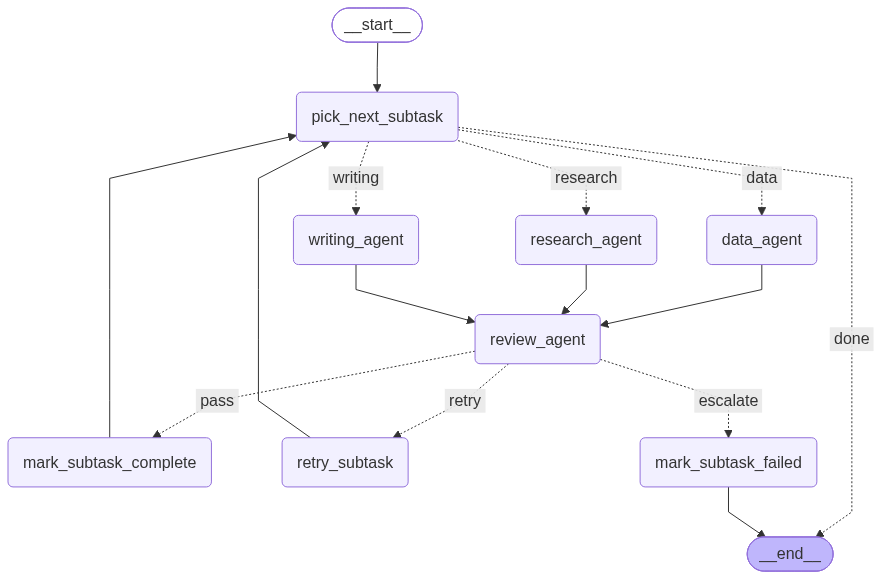

In [246]:
builder = StateGraph(SupervisorState)

builder.add_node("pick_next_subtask", pick_next_subtask)
builder.add_node("research_agent", research_agent)
builder.add_node("data_agent", data_agent)
builder.add_node("writing_agent", writing_agent)
builder.add_node("review_agent", review_agent)
builder.add_node("mark_subtask_complete", mark_subtask_complete)
builder.add_node("retry_subtask", retry_subtask)
builder.add_node("mark_subtask_failed", mark_subtask_failed)

builder.add_edge(START, "pick_next_subtask")

builder.add_conditional_edges(
    "pick_next_subtask",
    route_after_pick_next_subtask,
    {
        "research": "research_agent",
        "data": "data_agent",
        "writing": "writing_agent",
        "done": END,
    },
)

builder.add_edge("research_agent", "review_agent")
builder.add_edge("data_agent", "review_agent")
builder.add_edge("writing_agent", "review_agent")

builder.add_conditional_edges(
    "review_agent",
    route_after_subtask_review,
    {
        "pass": "mark_subtask_complete",
        "retry": "retry_subtask",
        "fail": "mark_subtask_failed",
        "escalate": "mark_subtask_failed",
    },
)

builder.add_edge("mark_subtask_complete", "pick_next_subtask")
builder.add_edge("retry_subtask", "pick_next_subtask")
builder.add_edge("mark_subtask_failed", END)

execute_specialists = builder.compile()
execute_specialists

In [247]:
builder = StateGraph(SupervisorState)

builder.add_node("initialise_task", initialise_task)
builder.add_node("supervisor_plan", supervisor_plan)
builder.add_node("execute_specialists", execute_specialists)
builder.add_node("aggregate_results", aggregate_results)
builder.add_node("final_review", final_review)
builder.add_node("return_response", return_response)
builder.add_node("escalate", escalate)

builder.add_edge(START, "initialise_task")
builder.add_edge("initialise_task", "supervisor_plan")

builder.add_conditional_edges(
    "supervisor_plan",
    route_after_planning,
    {
        "execute": "execute_specialists",
        "escalate": "escalate",
        "fail": "escalate",
    },
)

builder.add_edge("execute_specialists", "aggregate_results")
builder.add_edge("aggregate_results", "final_review")

builder.add_conditional_edges(
    "final_review",
    route_after_final_review,
    {
        "return": "return_response",
        "retry": "execute_specialists",
        "replan": "supervisor_plan",
        "escalate": "escalate",
    },
)

builder.add_edge("return_response", END)
builder.add_edge("escalate", END)

graph = builder.compile()

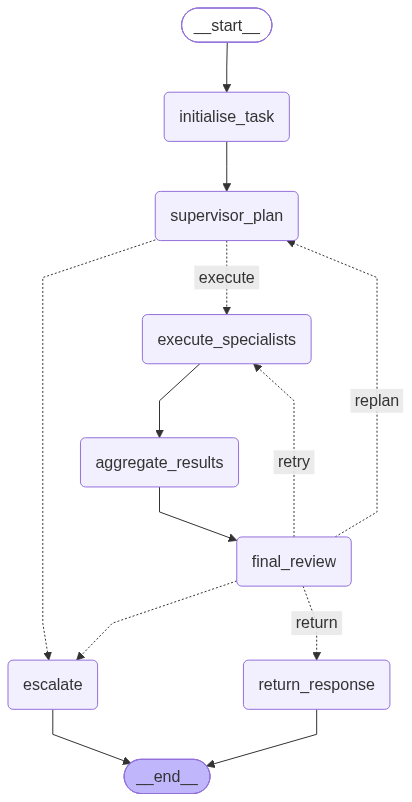

In [248]:
graph

In [249]:
def test_writing_context_excludes_previous_writing_results():
    state: SupervisorState = {
        "current_subtask_id": "s4",
        "subtasks": [
            {
                "id": "s1",
                "agent_type": "writing",
                "objective": "Write an earlier draft.",
                "expected_output": "Earlier content.",
                "tools_allowed": [],
                "review_criteria": [],
                "status": "passed",
                "retry_count": 0,
            },
            {
                "id": "s2",
                "agent_type": "research",
                "objective": "Collect facts.",
                "expected_output": "Research notes.",
                "tools_allowed": ["web_search"],
                "review_criteria": [],
                "status": "passed",
                "retry_count": 0,
            },
            {
                "id": "s3",
                "agent_type": "data",
                "objective": "Analyse facts.",
                "expected_output": "Structured analysis.",
                "tools_allowed": [],
                "review_criteria": [],
                "status": "failed",
                "retry_count": 1,
            },
            {
                "id": "s4",
                "agent_type": "writing",
                "objective": "Write the final answer.",
                "expected_output": "Final user-facing content.",
                "tools_allowed": [],
                "review_criteria": [],
                "status": "running",
                "retry_count": 0,
            },
        ],
        "subtask_results": {
            "s1": {
                "subtask_id": "s1",
                "agent_type": "writing",
                "output": {
                    "content": "THIS PREVIOUS WRITING CONTENT MUST NOT APPEAR."
                },
                "confidence": 0.9,
                "sources": [],
                "errors": [],
            },
            "s2": {
                "subtask_id": "s2",
                "agent_type": "research",
                "output": {
                    "summary": "Research found that the comparison should cover pricing, positioning, and features.",
                    "findings": [
                        {
                            "claim": "Competitor A is positioned as the budget option.",
                            "source": "Internal dummy source.",
                            "uncertainty": "Medium. Test fixture only.",
                        }
                    ],
                },
                "confidence": 0.88,
                "sources": [
                    {
                        "title": "Internal dummy source",
                        "source_type": "test_fixture",
                        "url": None,
                    }
                ],
                "errors": [],
            },
            "s3": {
                "subtask_id": "s3",
                "agent_type": "data",
                "output": {
                    "summary": "THIS FAILED DATA CONTENT MUST NOT APPEAR."
                },
                "confidence": 0.2,
                "sources": [],
                "errors": ["Data analysis failed."],
            },
        },
    }

    brief = format_upstream_specialist_brief(state)

    assert "Competitor A is positioned as the budget option." in brief
    assert "THIS PREVIOUS WRITING CONTENT MUST NOT APPEAR." not in brief
    assert "THIS FAILED DATA CONTENT MUST NOT APPEAR." not in brief

test_writing_context_excludes_previous_writing_results()

In [250]:
def test_writing_agent_returns_valid_subtask_result():
    state: SupervisorState = {
        "status": "executing",
        "user_request": "Write a short comparison of three competitors.",
        "current_subtask_id": "s3",
        "subtasks": [
            {
                "id": "s1",
                "agent_type": "research",
                "objective": "Collect relevant facts for the competitor comparison.",
                "expected_output": "Research notes with uncertainty marked.",
                "tools_allowed": ["web_search"],
                "review_criteria": [
                    "Findings are relevant.",
                    "Uncertainty is clearly marked.",
                ],
                "status": "passed",
                "retry_count": 0,
            },
            {
                "id": "s2",
                "agent_type": "data",
                "objective": "Structure the competitor comparison.",
                "expected_output": "Comparison points grouped by pricing, positioning, and features.",
                "tools_allowed": [],
                "review_criteria": [
                    "The comparison structure is clear.",
                    "The analysis uses the research notes.",
                ],
                "status": "passed",
                "retry_count": 0,
            },
            {
                "id": "s3",
                "agent_type": "writing",
                "objective": "Write a concise user-facing competitor comparison.",
                "expected_output": "A short comparison covering pricing, positioning, and feature differences.",
                "tools_allowed": [],
                "review_criteria": [
                    "The content is clear and concise.",
                    "The content uses upstream research and data context.",
                    "The content does not invent unsupported claims.",
                    "Uncertainty is clearly marked.",
                ],
                "status": "running",
                "retry_count": 0,
            },
        ],
        "subtask_results": {
            "s1": {
                "subtask_id": "s1",
                "agent_type": "research",
                "output": {
                    "summary": "The research suggests comparing competitors across pricing, positioning, and features.",
                    "findings": [
                        {
                            "claim": "Competitor A appears to be the budget option.",
                            "source": "Internal dummy source.",
                            "uncertainty": "Medium. This is test fixture data.",
                        },
                        {
                            "claim": "Competitor B appears to be the premium option.",
                            "source": "Internal dummy source.",
                            "uncertainty": "Medium. This is test fixture data.",
                        },
                        {
                            "claim": "Competitor C appears to be the flexible mid-market option.",
                            "source": "Internal dummy source.",
                            "uncertainty": "Medium. This is test fixture data.",
                        },
                    ],
                    "uncertainties": [
                        "This is dummy smoke-test context, not verified market research."
                    ],
                },
                "confidence": 0.9,
                "sources": [
                    {
                        "title": "Internal dummy source",
                        "source_type": "test_fixture",
                        "url": None,
                    }
                ],
                "errors": [],
            },
            "s2": {
                "subtask_id": "s2",
                "agent_type": "data",
                "output": {
                    "structured_points": [
                        {
                            "point": "Pricing: Competitor A is lowest, Competitor B is highest, Competitor C is mid-range.",
                            "basis": "Derived from dummy research notes.",
                        },
                        {
                            "point": "Positioning: Competitor A is budget-focused, Competitor B is premium-focused, Competitor C is flexibility-focused.",
                            "basis": "Derived from dummy research notes.",
                        },
                        {
                            "point": "Features: Competitor B has the strongest feature set, Competitor C is most configurable, Competitor A is simplest.",
                            "basis": "Derived from dummy research notes.",
                        },
                    ]
                },
                "confidence": 0.86,
                "sources": [],
                "errors": [],
            },
        },
        "review_reports": [],
    }

    updated_state = writing_agent(state)

    assert "subtask_results" in updated_state
    assert "s3" in updated_state["subtask_results"]

    result = updated_state["subtask_results"]["s3"]

    assert result["subtask_id"] == "s3"
    assert result["agent_type"] == "writing"
    assert 0.0 <= result["confidence"] <= 1.0
    assert result["errors"] == []
    assert "content" in result["output"]
    assert isinstance(result["output"]["content"], str)
    assert len(result["output"]["content"]) >= 20

    print(result["output"]["content"])

test_writing_agent_returns_valid_subtask_result()

A comparison of Competitor A, Competitor B, and Competitor C reveals distinct differences in pricing, positioning, and features. Competitor A is the budget option, with the lowest pricing, a budget-focused positioning, and a simple feature set. Competitor B is the premium option, with the highest pricing, a premium-focused positioning, and the strongest feature set. Competitor C falls in the mid-market, with mid-range pricing, a flexibility-focused positioning, and a highly configurable feature set. Note that these findings are based on dummy research context and should be treated with medium uncertainty.


In [251]:
def test_writing_agent_handles_missing_current_subtask():
    state: SupervisorState = {
        "status": "executing",
        "user_request": "Write a short comparison.",
        "current_subtask_id": None,
        "subtasks": [],
        "subtask_results": {},
        "review_reports": [],
    }

    updated_state = writing_agent(state)

    assert updated_state["error"] == "writing_agent called without a current subtask."
    assert updated_state["escalation_reason"] == "Missing current subtask."

test_writing_agent_handles_missing_current_subtask()

In [253]:
def test_full_graph_escalates_real_research_request_with_dummy_research_agent():
    result = graph.invoke(
        {
            "user_id": "user_001",
            "user_request": "Research three competitors and write a short comparison.",
        }
    )

    assert result["status"] == "escalated"
    assert result["final_answer"] is None

    assert result["escalation_reason"] is not None

    failed_or_escalated_subtasks = [
        subtask
        for subtask in result["subtasks"]
        if subtask["status"] in {"failed", "escalated"}
    ]

    assert len(failed_or_escalated_subtasks) >= 1

In [ ]:
def test_full_graph_completes_with_llm_supervisor_reviewer_and_writer():
    result = graph.invoke(
        {
            "user_id": "user_001",
            "user_request": "Research three competitors and write a short comparison.",
        }
    )

    assert result["status"] == "completed", {
        "status": result.get("status"),
        "error": result.get("error"),
        "escalation_reason": result.get("escalation_reason"),
        "subtasks": result.get("subtasks"),
        "review_reports": result.get("review_reports"),
        "final_review": result.get("final_review"),
        "subtask_results": result.get("subtask_results"),
    }

    assert result["error"] is None
    assert result["final_answer"] is not None
    assert len(result["final_answer"]) >= 20

    writing_results = [
        subtask_result
        for subtask_result in result["subtask_results"].values()
        if subtask_result["agent_type"] == "writing"
    ]

    assert len(writing_results) >= 1
    assert "content" in writing_results[-1]["output"]
    assert result["final_answer"] == writing_results[-1]["output"]["content"]

    for subtask in result["subtasks"]:
        assert subtask["status"] == "passed"

    for report in result["review_reports"]:
        assert 0.0 <= report["score"] <= 1.0

        if report["passed"]:
            assert report["action"] == "pass"
        else:
            assert report["action"] != "pass"
test_full_graph_completes_with_llm_supervisor_reviewer_and_writer()

AssertionError: {'status': 'escalated', 'error': None, 'escalation_reason': 'Subtask s1 failed after retries.', 'subtasks': [{'id': 's1', 'agent_type': 'research', 'objective': 'Research three competitors', 'expected_output': 'List of competitors with relevant information', 'tools_allowed': ['web_search'], 'review_criteria': ['Competitors are relevant to the industry', 'Information is accurate and up-to-date'], 'status': 'failed', 'retry_count': 0}, {'id': 's2', 'agent_type': 'data', 'objective': 'Compare the competitors', 'expected_output': 'Comparison of competitors', 'tools_allowed': [], 'review_criteria': ['Comparison is accurate and comprehensive', 'Data is properly structured'], 'status': 'pending', 'retry_count': 0}, {'id': 's3', 'agent_type': 'writing', 'objective': 'Write a short comparison', 'expected_output': 'Short comparison of competitors', 'tools_allowed': [], 'review_criteria': ['Writing is clear and concise', 'Comparison is well-organized and easy to understand'], 'sta

In [ ]:
def inspect_full_graph_run():
    result = graph.invoke(
        {
            "user_id": "user_001",
            "user_request": "Research three competitors and write a short comparison.",
        }
    )

    print("STATUS:", result.get("status"))
    print("ERROR:", result.get("error"))
    print("ESCALATION:", result.get("escalation_reason"))
    print("FINAL ANSWER:", result.get("final_answer"))

    print("\nPLAN:")
    print(result.get("plan"))

    print("\nSUBTASKS:")
    for subtask in result.get("subtasks", []):
        print(
            subtask.get("id"),
            subtask.get("agent_type"),
            subtask.get("status"),
            "retries:",
            subtask.get("retry_count"),
        )
        print("  objective:", subtask.get("objective"))
        print("  expected_output:", subtask.get("expected_output"))
        print("  review_criteria:", subtask.get("review_criteria"))

    print("\nSUBTASK RESULTS:")
    for subtask_id, subtask_result in result.get("subtask_results", {}).items():
        print(subtask_id, subtask_result.get("agent_type"))
        print("  confidence:", subtask_result.get("confidence"))
        print("  errors:", subtask_result.get("errors"))
        print("  output:", subtask_result.get("output"))

    print("\nREVIEW REPORTS:")
    for report in result.get("review_reports", []):
        print(report)

    print("\nFINAL REVIEW:")
    print(result.get("final_review"))

    return result


result = inspect_full_graph_run()

STATUS: escalated
ERROR: None
ESCALATION: Subtask s1 failed after retries.
FINAL ANSWER: This task needs human review before continuing. Reason: Subtask s1 failed after retries..

PLAN:
Research competitors and write a comparison

SUBTASKS:
s1 research failed retries: 2
  objective: Research three competitors
  expected_output: A list of three competitors with their key features and selling points
  review_criteria: ['The list includes three competitors', 'Each competitor has key features and selling points']
s2 data pending retries: 0
  objective: Compare the competitors
  expected_output: A comparison of the three competitors
  review_criteria: ['The comparison includes all three competitors', 'The comparison highlights the key differences and similarities']
s3 writing pending retries: 0
  objective: Write a short comparison
  expected_output: A short written comparison of the three competitors
  review_criteria: ['The comparison is well-written and concise', 'The comparison includes